<a href="https://colab.research.google.com/github/slogatskiy/DSCI-454_HW5/blob/main/DSCI454_HW5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("basketball_reference_dataset.csv")
df["postseason_rank"] = df["postseason_rank"].fillna(0)


**A view of the database:**







In [ ]:
print(df.shape)
display(df.head())

(596, 12)


,Team,season,W/L%,ORtg,DRtg,eFG%,3P%,TRB%,TOV%,Postseason,postseason_rank,net_rating
0,ATL,2002-2003,0.427,102.3,106.2,0.476,0.352,50.0,15.7,No Playoffs,0.0,-3.9
1,BOS,2002-2003,0.537,101.2,101.6,0.470,0.334,47.4,13.4,Playoffs,1.0,-0.4
2,CHI,2002-2003,0.366,100.2,105.6,0.471,0.350,48.9,15.4,No Playoffs,0.0,-5.4
3,CLE,2002-2003,0.207,96.6,106.7,0.444,0.327,51.7,16.4,No Playoffs,0.0,-10.1
4,DAL,2002-2003,0.732,110.7,102.4,0.498,0.381,48.1,10.9,Playoffs,1.0,8.3


**Correlation Heatmap:**

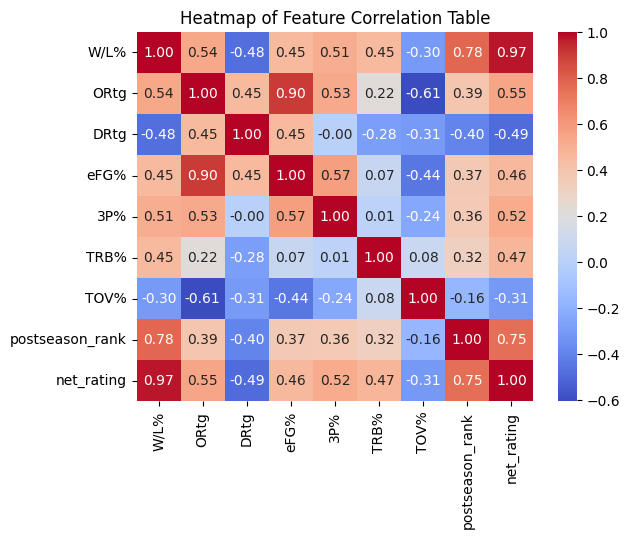

In [ ]:
numeric = df.select_dtypes(include=[np.number])
sns.heatmap(numeric.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap of Feature Correlation Table")
plt.show()

**Pair plot metrics colored by postseason classification :**

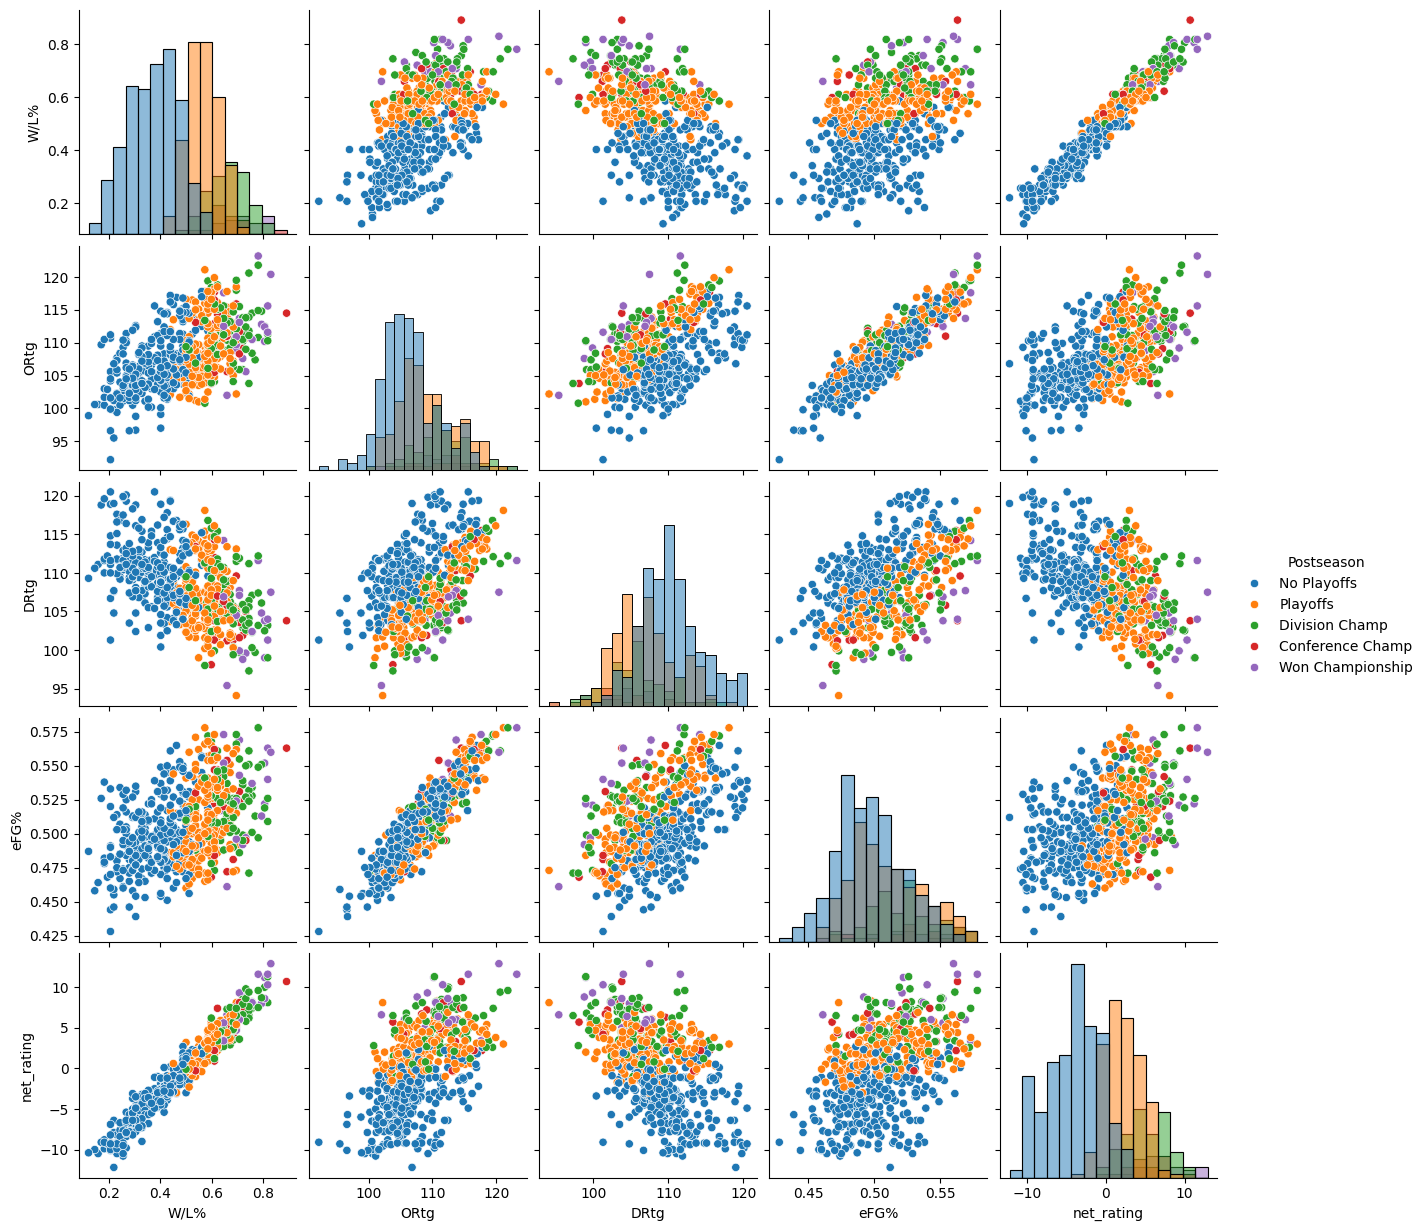

In [ ]:
pairplot_cols = ["W/L%", "ORtg", "DRtg", "eFG%", "net_rating"]
sns.pairplot(df[pairplot_cols + ["Postseason"]],hue="Postseason",diag_kind="hist")

**3 features relationship:**

<Axes: title={'center': 'Offensive Rating vs Win Percentage by Postseason Classification'}, xlabel='ORtg', ylabel='W/L%'>

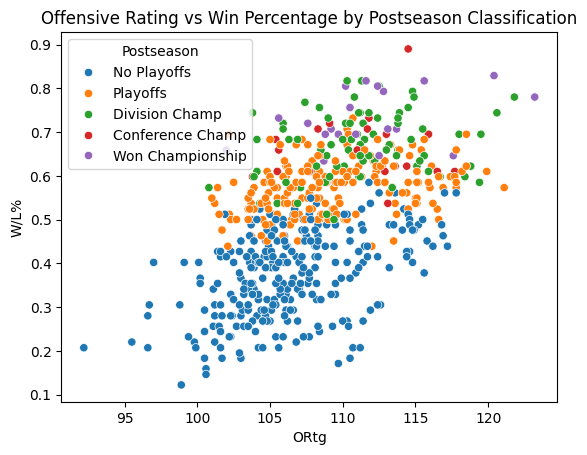

In [ ]:
plt.title("Offensive Rating vs Win Percentage by Postseason Classification")
sns.scatterplot(
    data=df,
    x="ORtg",
    y="W/L%",
    hue="Postseason"
)

**Histogram showing Distribution of Win Percentage:**

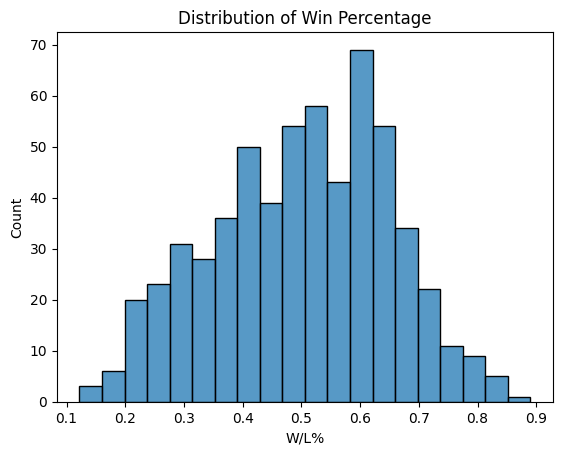

In [ ]:

sns.histplot(df["W/L%"], bins=20, kde=False)
plt.title("Distribution of Win Percentage")
plt.xlabel("W/L%")
plt.ylabel("Count")
plt.show()

**Line Chart showing Average Net Rating by:**

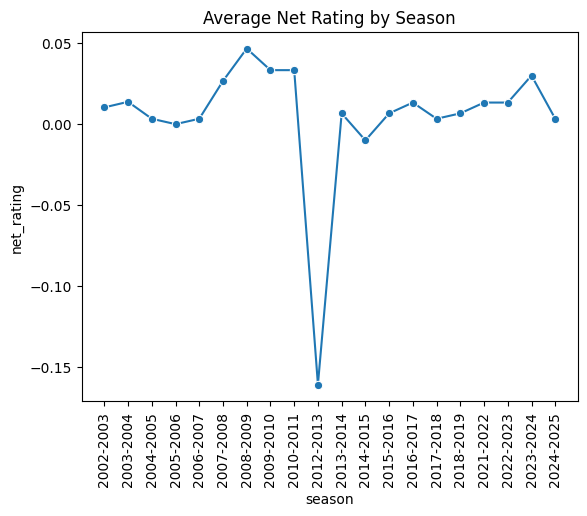

In [ ]:
season_avg = df.groupby("season", as_index=False)["net_rating"].mean()

sns.lineplot(data=season_avg, x="season", y="net_rating", marker="o")
plt.title("Average Net Rating by Season")
plt.xticks(rotation=90)
plt.show()

**Box plot representing Win Percentage by Postseason Classification:**

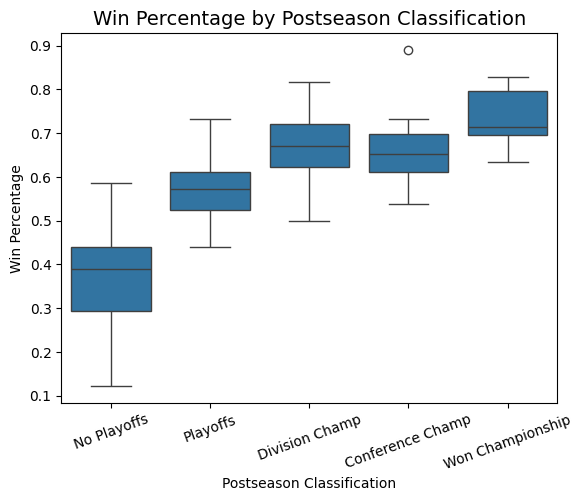

In [ ]:

sns.boxplot(data=df, x="Postseason", y="W/L%")
plt.title("Win Percentage by Postseason Classification", fontsize=14)
plt.xlabel("Postseason Classification")
plt.ylabel("Win Percentage")
plt.xticks(rotation=20)
plt.show()

**Bar chart showing Average 3P Percentage by Postseason Classification:**

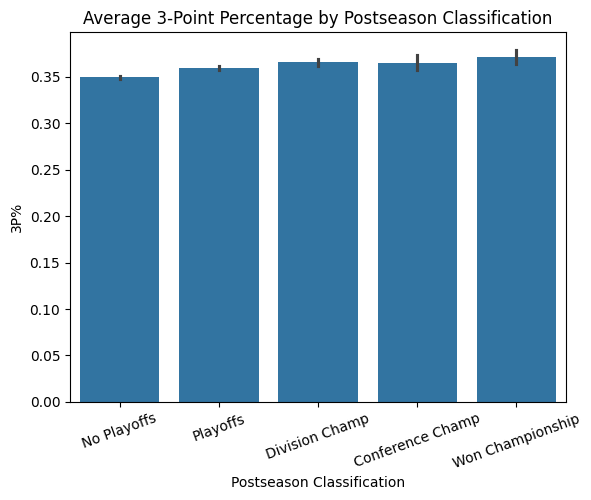

In [ ]:
sns.barplot(data=df,x="Postseason",y="3P%")
plt.title("Average 3-Point Percentage by Postseason Classification")
plt.xlabel("Postseason Classification")
plt.ylabel("3P%")
plt.xticks(rotation=20)
plt.show()

**Count chart of Teams by Postseason Classification:**

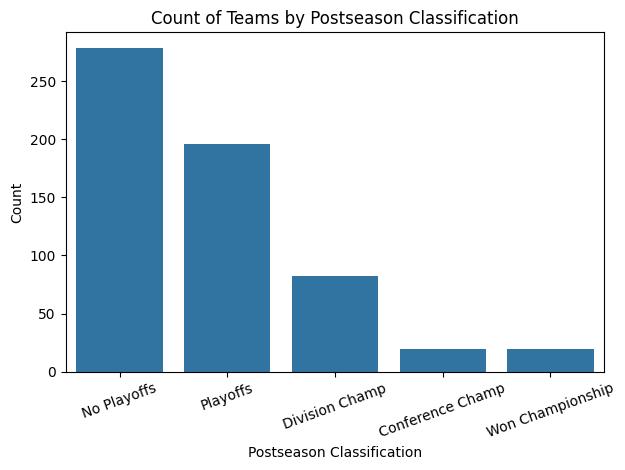

In [ ]:
sns.countplot(data=df, x="Postseason")
plt.title("Count of Teams by Postseason Classification")
plt.xlabel("Postseason Classification")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Interactive chart showing Averages by Postseason Classification:**

In [ ]:
stat_dropdown = widgets.Dropdown(
    options=["3P%", "eFG%", "ORtg", "DRtg", "net_rating", "W/L%"],
    value="3P%",
    description="Stat:"
)

def update_chart(stat):
    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=df,
        x="Postseason",
        y=stat
    )
    plt.title(f"Average {stat} by Postseason Classification")
    plt.xlabel("Postseason Classification")
    plt.ylabel(stat)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

display(widgets.interactive(update_chart, stat=stat_dropdown))

interactive(children=(Dropdown(description='Stat:', options=('3P%', 'eFG%', 'ORtg', 'DRtg', 'net_rating', 'W/L…